## Taller 6 Sumin Han- Juan David Nieto Dallos 


In [1]:
import pandas as pd


df = pd.read_csv("Country-data.csv")
print("DataFrame cargado desde", "Country-data.csv")
print("Número de filas y columnas:", df.shape)
print(df.head())


DataFrame cargado desde Country-data.csv
Número de filas y columnas: (167, 10)
               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  
0       9.44        56.2       5.82    553  
1       4.49        76.3       1.65   4090  
2      16.10        76.5       2.89   4460  
3      22.40        60.1       6.16   3530  
4       1.44        76.8       2.13  12200  


In [2]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

print(pd.DataFrame({'Valores faltantes': missing, 'Porcentaje (%)': missing_pct}))

if missing.sum() == 0:
    print('\nNo hay valores faltantes en el dataset.')
else:
    numeric_cols = df.select_dtypes(include='number').columns
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
    print('\nValores faltantes imputados con la mediana de cada variable.')

print(f'\nFilas duplicadas: {df.duplicated().sum()}')

            Valores faltantes  Porcentaje (%)
country                     0             0.0
child_mort                  0             0.0
exports                     0             0.0
health                      0             0.0
imports                     0             0.0
income                      0             0.0
inflation                   0             0.0
life_expec                  0             0.0
total_fer                   0             0.0
gdpp                        0             0.0

No hay valores faltantes en el dataset.

Filas duplicadas: 0


In [3]:
from sklearn.preprocessing import StandardScaler
features = ['child_mort', 'exports', 'health', 'imports', 'income',
            'inflation', 'life_expec', 'total_fer', 'gdpp']

X = df[features].copy()

print('\nRangos ANTES del escalado:')
print(X.agg(['min', 'max']).T)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features, index=df.index)

print('\nEstadísticas DESPUÉS del escalado (media ≈ 0, std ≈ 1):')
print(X_scaled.describe().loc[['mean', 'std', 'min', 'max']].round(4))


Rangos ANTES del escalado:
                 min        max
child_mort    2.6000     208.00
exports       0.1090     200.00
health        1.8100      17.90
imports       0.0659     174.00
income      609.0000  125000.00
inflation    -4.2100     104.00
life_expec   32.1000      82.80
total_fer     1.1500       7.49
gdpp        231.0000  105000.00

Estadísticas DESPUÉS del escalado (media ≈ 0, std ≈ 1):
      child_mort  exports  health  imports  income  inflation  life_expec  \
mean     -0.0000   0.0000  0.0000   0.0000 -0.0000    -0.0000      0.0000   
std       1.0030   1.0030  1.0030   1.0030  1.0030     1.0030      1.0030   
min      -0.8871  -1.5002 -1.8278  -1.9399 -0.8603    -1.1379     -4.3372   
max       4.2213   5.8138  4.0474   5.2662  5.6115     9.1297      1.3810   

      total_fer    gdpp  
mean     0.0000  0.0000  
std      1.0030  1.0030  
min     -1.1913 -0.6968  
max      3.0093  5.0365  


In [4]:
from sklearn.cluster import KMeans
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    
    # Centroides en escala original (más interpretable)
    centroides_orig = scaler.inverse_transform(km.cluster_centers_)
    centroides_df = pd.DataFrame(centroides_orig, columns=features)
    centroides_df.index.name = 'Cluster'
    
    print(f'{"="*60}')
    print(f'  K = {k}  |  Inercia = {km.inertia_:.2f}')
    print(f'{"="*60}')
    print('Centroides (escala original):')
    print(centroides_df.round(2).to_string())
    print()

  K = 2  |  Inercia = 1050.21
Centroides (escala original):
         child_mort  exports  health  imports    income  inflation  life_expec  total_fer      gdpp
Cluster                                                                                            
0             12.16     48.6    7.31    49.12  26017.17        5.5       76.49       1.94  20507.98
1             76.28     30.2    6.09    43.64   4227.40       11.1       61.91       4.41   1981.24

  K = 3  |  Inercia = 831.42
Centroides (escala original):
         child_mort  exports  health  imports    income  inflation  life_expec  total_fer      gdpp
Cluster                                                                                            
0              5.00    58.74    8.81    51.49  45672.22       2.67       80.13       1.75  42494.44
1             92.96    29.15    6.39    42.32   3942.40      12.02       59.19       5.01   1922.38
2             21.93    40.24    6.20    47.47  12305.60       7.60       72.81  

#### K=3 es el valor óptimo. Ofrece el mejor balance entre reducción de inercia y simplicidad interpretativa, agrupando los países en tres categorías económicas coherentes: desarrollados, en desarrollo y subdesarrollados. Aumentar K solo fragmenta grupos ya bien definidos sin aportar información nueva sustancial.

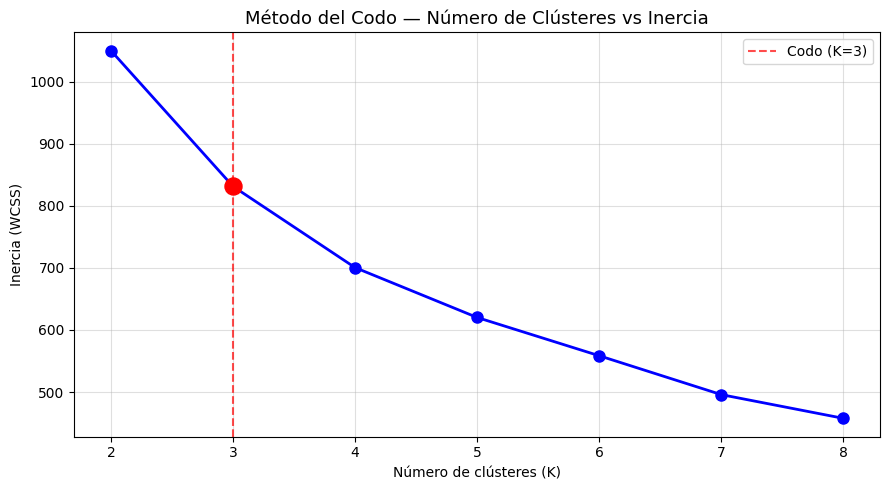

Inercias por K:
  K=2: 1050.21
  K=3: 831.42
  K=4: 700.52
  K=5: 620.16
  K=6: 558.47
  K=7: 495.81
  K=8: 457.59


In [5]:
import matplotlib.pyplot as plt

inertias = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# Gráfica del codo
plt.figure(figsize=(9, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)

# Marcar el codo en K=3
plt.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='Codo (K=3)')
plt.scatter([3], [inertias[1]], color='red', s=150, zorder=5)

plt.title('Método del Codo — Número de Clústeres vs Inercia', fontsize=13)
plt.xlabel('Número de clústeres (K)')
plt.ylabel('Inercia (WCSS)')
plt.xticks(K_range)
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print('Inercias por K:')
for k, inercia in zip(K_range, inertias):
    print(f'  K={k}: {inercia:.2f}')


#### De K=2 a K=3 se produce una caida mas pronunciada, indicando que pasar de 2 a 3 grupos captura una diferencia estructural real en los datos. 

#### A partir de K=4 en adelante la curva se va aplanado progresivamente cada cluster adicional aporta reducciones cada vez menores. 

Silhouette Score global (K=3): 0.2833
Calidad: Clustering DÉBIL


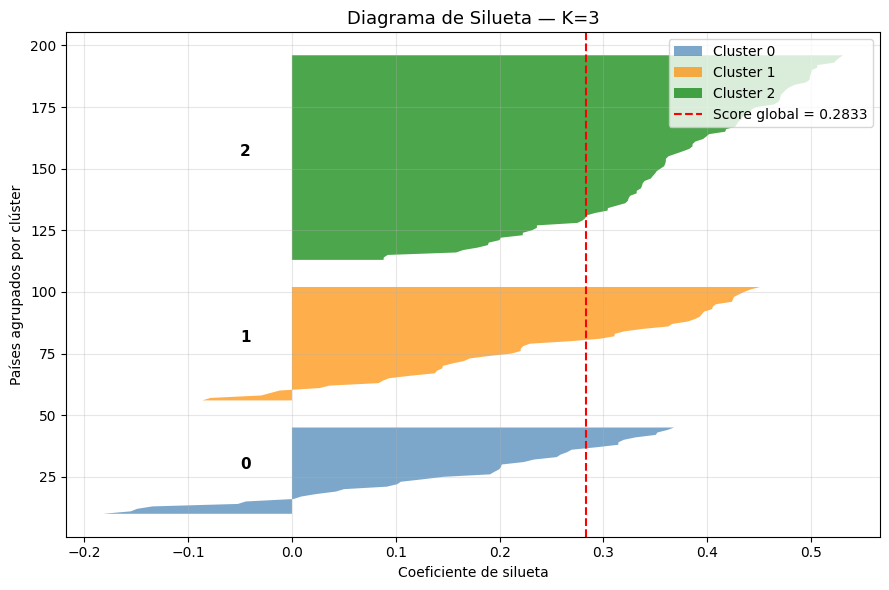


Colombia pertenece al Clúster 2

Datos de Colombia:
 child_mort  exports  health  imports  income  inflation  life_expec  total_fer  gdpp
       18.6     15.9    7.59     17.8   10900       3.86        76.4       2.01  6250

Centroide de su clúster (escala original):
child_mort       21.93
exports          40.24
health            6.20
imports          47.47
income        12305.60
inflation         7.60
life_expec       72.81
total_fer         2.31
gdpp           6486.45


In [6]:
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

#  Modelo final con K=3 
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X_scaled)

score = silhouette_score(X_scaled, df['cluster'])
print(f'Silhouette Score global (K=3): {score:.4f}')

if score >= 0.71:
    calidad = 'Clustering FUERTE'
elif score >= 0.51:
    calidad = 'Clustering RAZONABLEMENTE BUENO'
elif score >= 0.26:
    calidad = 'Clustering DÉBIL'
else:
    calidad = 'Clustering MUY POBRE'
print(f'Calidad: {calidad}')

#  Gráfica de silueta
silhouette_vals = silhouette_samples(X_scaled, df['cluster'])

fig, ax = plt.subplots(figsize=(9, 6))
y_lower = 10
colors = ['steelblue', 'darkorange', 'green']

for i in range(3):
    cluster_vals = np.sort(silhouette_vals[df['cluster'] == i])
    size = cluster_vals.shape[0]
    y_upper = y_lower + size

    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_vals,
                     facecolor=colors[i], alpha=0.7, label=f'Cluster {i}')
    ax.text(-0.05, y_lower + size / 2, str(i), fontsize=11, fontweight='bold')
    y_lower = y_upper + 10

ax.axvline(x=score, color='red', linestyle='--', linewidth=1.5,
           label=f'Score global = {score:.4f}')
ax.set_title('Diagrama de Silueta — K=3', fontsize=13)
ax.set_xlabel('Coeficiente de silueta')
ax.set_ylabel('Países agrupados por clúster')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#  Colombia 
colombia = df[df['country'] == 'Colombia']
cluster_col = colombia['cluster'].values[0]

print(f'\nColombia pertenece al Clúster {cluster_col}')
print('\nDatos de Colombia:')
print(colombia[features].to_string(index=False))
print('\nCentroide de su clúster (escala original):')
centroide = scaler.inverse_transform(kmeans_final.cluster_centers_)[cluster_col]
print(pd.Series(centroide, index=features).round(2).to_string())


#### El Score de 0.2833 indica un clustering debil, lo que es normal en datos socioeconomicos donde el desarrollo de un pais. Colombia esta bien ubicada en el Cluster 2 (paises en desarrollo). 

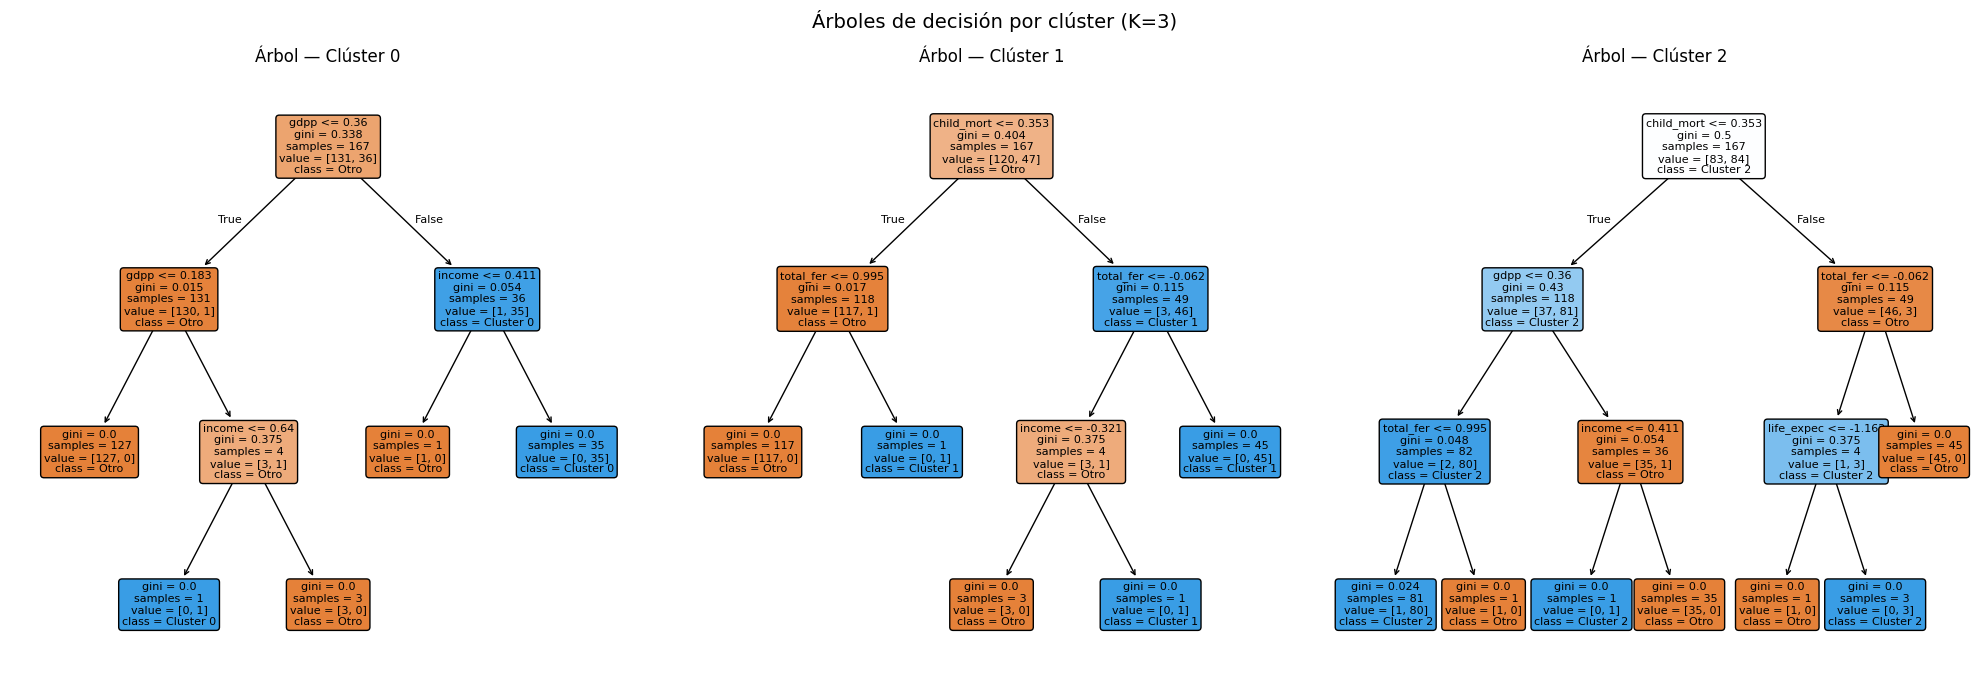


Variables más importantes por clúster:

  Clúster 0: gdpp (0.94), income (0.06), child_mort (0.00)

  Clúster 1: child_mort (0.89), total_fer (0.09), income (0.02)

  Clúster 2: gdpp (0.55), child_mort (0.33), total_fer (0.07)


In [7]:
#  Árbol de decisión por clúster 
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for c in range(3):
    # Etiqueta binaria: 1 si pertenece a este clúster, 0 si no
    y_bin = (df['cluster'] == c).astype(int)

    tree = DecisionTreeClassifier(max_depth=3, random_state=42)
    tree.fit(X_scaled, y_bin)

    plot_tree(tree, feature_names=features, class_names=['Otro', f'Cluster {c}'],
              filled=True, rounded=True, fontsize=8, ax=axes[c])
    axes[c].set_title(f'Árbol — Clúster {c}', fontsize=12)

plt.suptitle('Árboles de decisión por clúster (K=3)', fontsize=14)
plt.tight_layout()
plt.show()

# Importancia de variables por clúster
print('\nVariables más importantes por clúster:')
for c in range(3):
    y_bin = (df['cluster'] == c).astype(int)
    tree = DecisionTreeClassifier(max_depth=3, random_state=42)
    tree.fit(X_scaled, y_bin)
    importancias = pd.Series(tree.feature_importances_, index=features)
    top3 = importancias.nlargest(3)
    print(f'\n  Clúster {c}: {", ".join([f"{v} ({s:.2f})" for v, s in top3.items()])}')


## Clúster 0 — Países desarrollados
#### La variable determinante es gdpp (94%). Un país entra a este grupo si tiene un PIB per cápita alto. El árbol lo confirma: la primera división es gdpp <= 0.36 (en escala estandarizada, ~$20,000). El ingreso por persona actúa como criterio secundario para afinar casos límite.

## Clúster 1 — Países subdesarrollados
#### La variable clave es child_mort. Una mortalidad infantil alta es el indicador más contundente de pobreza y precariedad. El árbol lo refleja desde la raíz: child_mort <= 0.353. La tasa de fertilidad (total_fer) aparece como segundo criterio, lo que tiene sentido pues países con alta mortalidad infantil tienden también a tener más hijos por mujer.

## Clúster 2 — Países en desarrollo
#### Es el más complejo: gdpp y child_mort comparten el peso. Esto refleja que este grupo es heterogéneo — no hay una sola variable que lo defina claramente, sino una combinación de PIB moderado y mortalidad intermedia.